<a href="https://colab.research.google.com/github/sevval-345/SoftITo/blob/main/derin_ogrenme_giris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Derin Öğrenmeye Giriş

---

Bu notebook, derin öğrenmenin temel kavramlarını sıfırdan açıklayan kapsamlı bir giriş rehberidir.

**İçindekiler:**
1. Yapay Zeka, Makine Öğrenmesi ve Derin Öğrenme Farkı
2. Yapay Sinir Ağları (ANN)
3. Aktivasyon Fonksiyonları
4. İleri Yayılım (Forward Propagation)
5. Kayıp Fonksiyonu ve Geri Yayılım
6. Eğitim Döngüsü
7. PyTorch ile İlk Sinir Ağı
8. MNIST ile Görüntü Sınıflandırma
9. Overfitting ve Regularizasyon
10. Sonuç ve Kaynaklar

In [1]:
# Gerekli kütüphaneleri yükleme
# Eğer yüklü değilse: pip install torch torchvision matplotlib numpy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

# Reproducibility için seed ayarla
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch Versiyonu : {torch.__version__}")
print(f"GPU Kullanılabilir : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz  : {device}")

PyTorch Versiyonu : 2.10.0+cpu
GPU Kullanılabilir : False
Kullanılan Cihaz  : cpu


## 2. Yapay Sinir Ağları (Artificial Neural Networks)

İnsan beynindeki nöronlardan ilham alınarak tasarlanmıştır.

### Bir Nöronun Yapısı
```
x₁ ──w₁──┐
x₂ ──w₂──┤──→ [Σ + bias] ──→ [Aktivasyon] ──→ çıktı
x₃ ──w₃──┘
```

**Matematiksel ifade:**
$$z = w_1x_1 + w_2x_2 + w_3x_3 + b$$
$$\hat{y} = f(z)$$

- **x**: Girdiler (inputs)
- **w**: Ağırlıklar (weights) — modelin öğrendiği parametreler
- **b**: Yanlılık (bias) — eşik değeri
- **f**: Aktivasyon fonksiyonu

In [2]:
# Tek bir nöronu sıfırdan oluşturalım

class Noron:
    """Tek bir yapay nöron."""

    def __init__(self, girdi_sayisi):
        # Ağırlıkları ve bias'ı rastgele başlat
        self.agirliklar = np.random.randn(girdi_sayisi)  # shape: (n,)
        self.bias = np.random.randn()                   # tek sayı

    def ileri_gecis(self, x):
        """Nörondan bir ileri geçiş yap."""
        # Ağırlıklı toplam: z = w·x + b
        z = np.dot(self.agirliklar, x) + self.bias
        # Aktivasyon (şimdilik yok, sonra ekleyeceğiz)
        return z

# Test edelim
noron = Noron(girdi_sayisi=3)
x_ornek = np.array([1.0, 2.0, 3.0])

print("Girdiler     :", x_ornek)
print("Ağırlıklar   :", noron.agirliklar)
print("Bias         :", noron.bias)
print("Çıktı (z)    :", noron.ileri_gecis(x_ornek))

Girdiler     : [1. 2. 3.]
Ağırlıklar   : [ 0.49671415 -0.1382643   0.64768854]
Bias         : 1.5230298564080254
Çıktı (z)    : 3.6862810213789663


## 3. Aktivasyon Fonksiyonları

Nörona **doğrusal olmama (non-linearity)** katarlar. Bu olmadan, ne kadar katman eklesek de model sadece doğrusal bir fonksiyon öğrenebilir.

| Fonksiyon | Formül | Kullanım Yeri |
|---|---|---|
| **Sigmoid** | 1/(1+e⁻ˣ) | İkili sınıflandırma çıktısı |
| **ReLU** | max(0, x) | Gizli katmanlar (en yaygın) |
| **Tanh** | (eˣ-e⁻ˣ)/(eˣ+e⁻ˣ) | RNN'lerde |
| **Softmax** | eˣᵢ/Σeˣⱼ | Çok sınıflı çıktı |

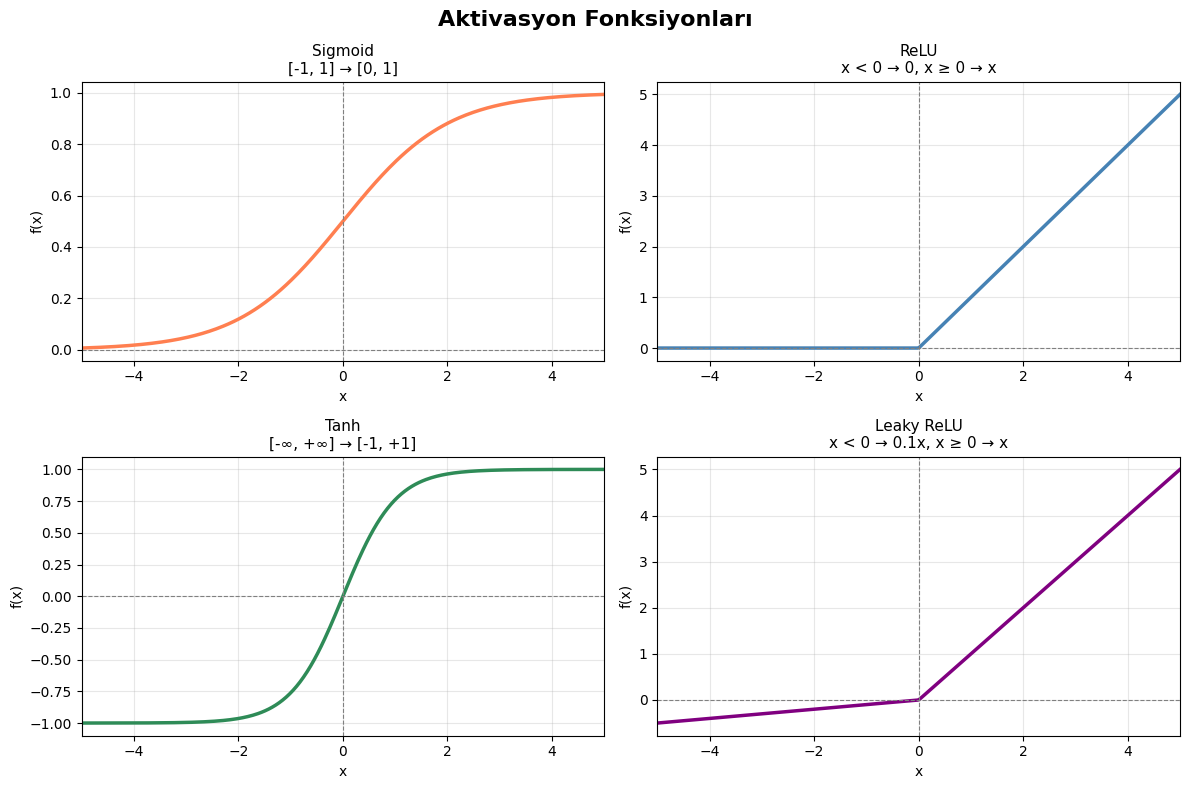

✅ ReLU bugün gizli katmanlarda en çok tercih edilen aktivasyondur.


In [3]:
# Aktivasyon fonksiyonlarını görselleştir

x = np.linspace(-5, 5, 300)

# Fonksiyon tanımları
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

def leaky_relu(x, alpha=0.1):
    # Negatif tarafta küçük bir eğim var (ölü ReLU sorununu azaltır)
    return np.where(x > 0, x, alpha * x)

# Görselleştirme
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Aktivasyon Fonksiyonları', fontsize=16, fontweight='bold')

fonksiyonlar = [
    (sigmoid, 'Sigmoid', 'coral', '[-1, 1] → [0, 1]'),
    (relu, 'ReLU', 'steelblue', 'x < 0 → 0, x ≥ 0 → x'),
    (tanh, 'Tanh', 'seagreen', '[-∞, +∞] → [-1, +1]'),
    (leaky_relu, 'Leaky ReLU', 'purple', 'x < 0 → 0.1x, x ≥ 0 → x'),
]

for ax, (fonk, isim, renk, aciklama) in zip(axes.flat, fonksiyonlar):
    y = fonk(x)
    ax.plot(x, y, color=renk, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'{isim}\n{aciklama}', fontsize=11)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-5, 5)

plt.tight_layout()
plt.show()
print("✅ ReLU bugün gizli katmanlarda en çok tercih edilen aktivasyondur.")

## 4. İleri Yayılım (Forward Propagation)

Girdi verisinin ağ boyunca ilerleyerek bir tahmin üretmesi sürecidir.

```
Girdi Katmanı     Gizli Katman      Çıktı Katmanı
    x₁               h₁
    x₂  ──────────→  h₂  ──────────→  ŷ
    x₃               h₃
```

**Her katman için:** `H = f(XW + b)`

In [4]:
# İleri yayılımı NumPy ile sıfırdan yazalım

class BasitSinirAgi:
    """
    2 katmanlı (1 gizli) sinir ağı.
    Mimari: girdi → gizli (ReLU) → çıktı (Sigmoid)
    """

    def __init__(self, girdi_boyutu, gizli_boyut, cikti_boyutu):
        # Katman 1 parametreleri: W1 (girdi→gizli), b1
        self.W1 = np.random.randn(girdi_boyutu, gizli_boyut) * 0.01
        self.b1 = np.zeros((1, gizli_boyut))

        # Katman 2 parametreleri: W2 (gizli→çıktı), b2
        self.W2 = np.random.randn(gizli_boyut, cikti_boyutu) * 0.01
        self.b2 = np.zeros((1, cikti_boyutu))

    def relu(self, z):
        """ReLU aktivasyon fonksiyonu."""
        return np.maximum(0, z)

    def sigmoid(self, z):
        """Sigmoid aktivasyon fonksiyonu."""
        return 1 / (1 + np.exp(-z))

    def ileri_yayilim(self, X):
        """
        X: girdi matrisi, shape (batch_size, girdi_boyutu)
        Dönüş: tahminler, shape (batch_size, cikti_boyutu)
        """
        # Katman 1: doğrusal dönüşüm + ReLU
        self.Z1 = X @ self.W1 + self.b1    # (batch, gizli)
        self.A1 = self.relu(self.Z1)        # ReLU aktivasyonu

        # Katman 2: doğrusal dönüşüm + Sigmoid
        self.Z2 = self.A1 @ self.W2 + self.b2  # (batch, çıktı)
        self.A2 = self.sigmoid(self.Z2)         # Sigmoid aktivasyonu

        return self.A2

# Test edelim
model = BasitSinirAgi(girdi_boyutu=4, gizli_boyut=8, cikti_boyutu=1)

# 5 örnek, 4 özellikli sahte veri
X_test = np.random.randn(5, 4)
tahmin = model.ileri_yayilim(X_test)

print("Girdi şekli  :", X_test.shape)
print("Tahmin şekli :", tahmin.shape)
print("Tahminler    :", tahmin.flatten().round(4))
print("\n(Tüm değerler 0-1 arasında çünkü sigmoid kullandık ✓)")

Girdi şekli  : (5, 4)
Tahmin şekli : (5, 1)
Tahminler    : [0.5    0.4997 0.5    0.5    0.4999]

(Tüm değerler 0-1 arasında çünkü sigmoid kullandık ✓)


## 5. Kayıp Fonksiyonu ve Geri Yayılım

### Kayıp Fonksiyonu (Loss Function)
Modelin ne kadar yanlış tahmin ettiğini ölçer.

| Problem Türü | Kayıp Fonksiyonu | Formül |
|---|---|---|
| İkili Sınıflandırma | Binary Cross-Entropy | -[y·log(ŷ) + (1-y)·log(1-ŷ)] |
| Çok Sınıflı | Categorical Cross-Entropy | -Σ yᵢ·log(ŷᵢ) |
| Regresyon | MSE | (1/n)·Σ(y - ŷ)² |

### Geri Yayılım (Backpropagation)
Zincir kuralı (chain rule) ile her ağırlığın hataya katkısını hesaplar:
$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial W}$$

### Gradient Descent (Gradyan İnişi)
$$W \leftarrow W - \alpha \cdot \frac{\partial L}{\partial W}$$
- **α (alpha)**: Öğrenme hızı (learning rate)

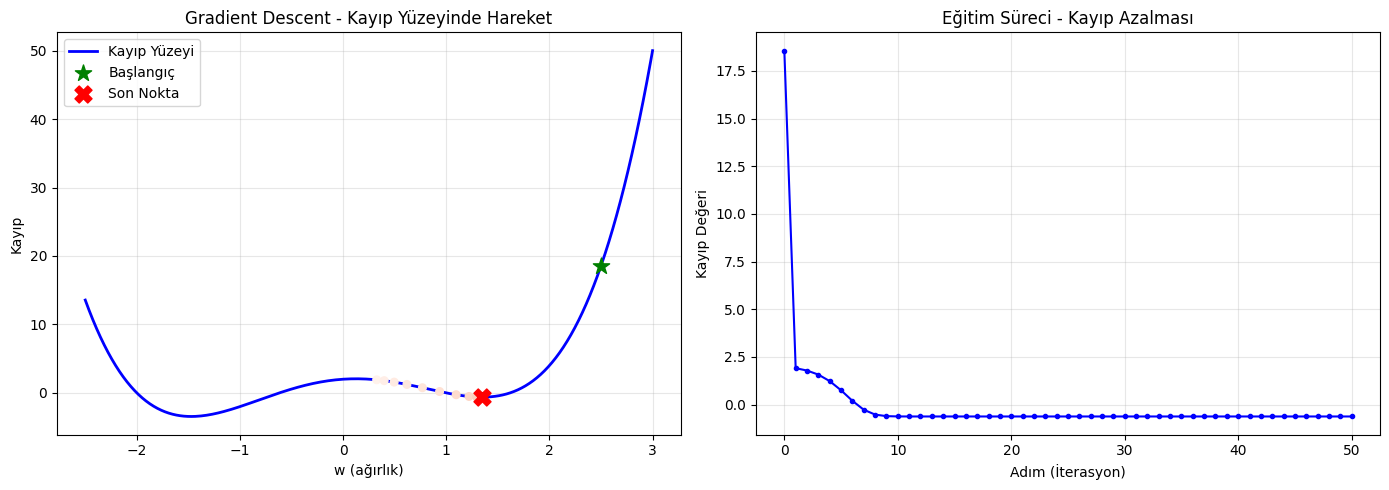

Başlangıç kaybı : 18.5625
Son kayıp       : -0.6186


In [5]:
# Gradient Descent'i 1D'de görselleştirelim

def kayip_fonksiyonu(w):
    """Örnek kayıp yüzeyi: f(w) = w^4 - 4w^2 + w + 2"""
    return w**4 - 4*w**2 + w + 2

def gradient(w):
    """Analitik türev: f'(w) = 4w^3 - 8w + 1"""
    return 4*w**3 - 8*w + 1

# Gradient Descent simülasyonu
ogrenme_hizi = 0.05
w = 2.5           # başlangıç noktası
adimlar = 50

w_gecmis = [w]
kayip_gecmis = [kayip_fonksiyonu(w)]

for _ in range(adimlar):
    grad = gradient(w)         # gradyanı hesapla
    w = w - ogrenme_hizi * grad  # ağırlığı güncelle
    w_gecmis.append(w)
    kayip_gecmis.append(kayip_fonksiyonu(w))

# Görselleştirme
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

w_aralik = np.linspace(-2.5, 3, 300)
ax1.plot(w_aralik, kayip_fonksiyonu(w_aralik), 'b-', linewidth=2, label='Kayıp Yüzeyi')
ax1.scatter(w_gecmis, [kayip_fonksiyonu(wi) for wi in w_gecmis],
            c=range(len(w_gecmis)), cmap='Reds', s=30, zorder=5)
ax1.scatter(w_gecmis[0], kayip_fonksiyonu(w_gecmis[0]),
            color='green', s=150, marker='*', zorder=6, label='Başlangıç')
ax1.scatter(w_gecmis[-1], kayip_fonksiyonu(w_gecmis[-1]),
            color='red', s=150, marker='X', zorder=6, label='Son Nokta')
ax1.set_title('Gradient Descent - Kayıp Yüzeyinde Hareket', fontsize=12)
ax1.set_xlabel('w (ağırlık)')
ax1.set_ylabel('Kayıp')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(kayip_gecmis, 'b-o', markersize=3)
ax2.set_title('Eğitim Süreci - Kayıp Azalması', fontsize=12)
ax2.set_xlabel('Adım (İterasyon)')
ax2.set_ylabel('Kayıp Değeri')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Başlangıç kaybı : {kayip_gecmis[0]:.4f}")
print(f"Son kayıp       : {kayip_gecmis[-1]:.4f}")

## 6. PyTorch ile İlk Sinir Ağı

Artık PyTorch kullanarak gerçek bir model oluşturalım. PyTorch'un avantajları:
- **Otomatik türev** (autograd) — geri yayılımı elle yazmaya gerek yok
- **GPU desteği** — tek satırla CUDA'ya geçiş
- **Dinamik hesap grafiği** — hata ayıklaması kolaylığı

In [6]:
# PyTorch ile basit bir sınıflandırma problemi
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── 1. VERİ HAZIRLAMA ──────────────────────────────────────
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.4, random_state=42)
X = StandardScaler().fit_transform(X)   # Normalleştir

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# NumPy → PyTorch Tensor
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).unsqueeze(1).to(device)  # (n,) → (n, 1)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_test_t  = torch.FloatTensor(y_test).unsqueeze(1).to(device)

# ── 2. MODEL TANIMI ────────────────────────────────────────
class DaireAyirici(nn.Module):
    """
    İç içe daireleri ayırt eden 3 katmanlı sinir ağı.
    """
    def __init__(self):
        super(DaireAyirici, self).__init__()

        # nn.Sequential: katmanları sırayla tanımlar
        self.aglar = nn.Sequential(
            nn.Linear(2, 16),   # Girdi: 2 özellik (x, y koordinatı)
            nn.ReLU(),
            nn.Linear(16, 16),
            nn.ReLU(),
            nn.Linear(16, 1),   # Çıktı: 1 sayı (0 veya 1)
            nn.Sigmoid()        # [0, 1] aralığına sıkıştır
        )

    def forward(self, x):
        """forward() metodu ileri yayılımı tanımlar."""
        return self.aglar(x)

model = DaireAyirici().to(device)

# ── 3. EĞİTİM AYARLARI ────────────────────────────────────
kayip_fn  = nn.BCELoss()                           # Binary Cross-Entropy
optimizer = optim.Adam(model.parameters(), lr=0.01) # Adam optimizer

print("Model Mimarisi:")
print(model)
print(f"\nToplam Parametre Sayısı: {sum(p.numel() for p in model.parameters()):,}")

Model Mimarisi:
DaireAyirici(
  (aglar): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Toplam Parametre Sayısı: 337


In [7]:
# ── 4. EĞİTİM DÖNGÜSÜ ─────────────────────────────────────

epochs = 200
kayip_gecmisi = []
dogruluk_gecmisi = []

for epoch in range(epochs):
    model.train()              # Eğitim moduna geç (dropout aktif vb.)

    # İleri yayılım
    tahmin = model(X_train_t)  # ŷ
    kayip  = kayip_fn(tahmin, y_train_t)  # L(ŷ, y)

    # Geri yayılım
    optimizer.zero_grad()  # Önceki gradyanları sıfırla (önemli!)
    kayip.backward()       # Gradyanları hesapla (autograd)
    optimizer.step()       # Ağırlıkları güncelle

    # Doğruluk hesapla (eğitim seti)
    with torch.no_grad():  # Değerlendirme sırasında gradyan hesaplama
        model.eval()
        pred_label = (tahmin > 0.5).float()
        dogruluk   = (pred_label == y_train_t).float().mean().item()

    kayip_gecmisi.append(kayip.item())
    dogruluk_gecmisi.append(dogruluk)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1:3d}/{epochs}] → Kayıp: {kayip.item():.4f} | Doğruluk: {dogruluk*100:.1f}%")

# Test seti değerlendirme
model.eval()
with torch.no_grad():
    test_pred = model(X_test_t)
    test_kayip = kayip_fn(test_pred, y_test_t)
    test_dogruluk = ((test_pred > 0.5).float() == y_test_t).float().mean().item()

print(f"\n{'='*45}")
print(f"Test Kaybı    : {test_kayip.item():.4f}")
print(f"Test Doğruluğu: {test_dogruluk*100:.1f}%")

Epoch [ 50/200] → Kayıp: 0.0397 | Doğruluk: 100.0%
Epoch [100/200] → Kayıp: 0.0037 | Doğruluk: 100.0%
Epoch [150/200] → Kayıp: 0.0018 | Doğruluk: 100.0%
Epoch [200/200] → Kayıp: 0.0011 | Doğruluk: 100.0%

Test Kaybı    : 0.0085
Test Doğruluğu: 100.0%


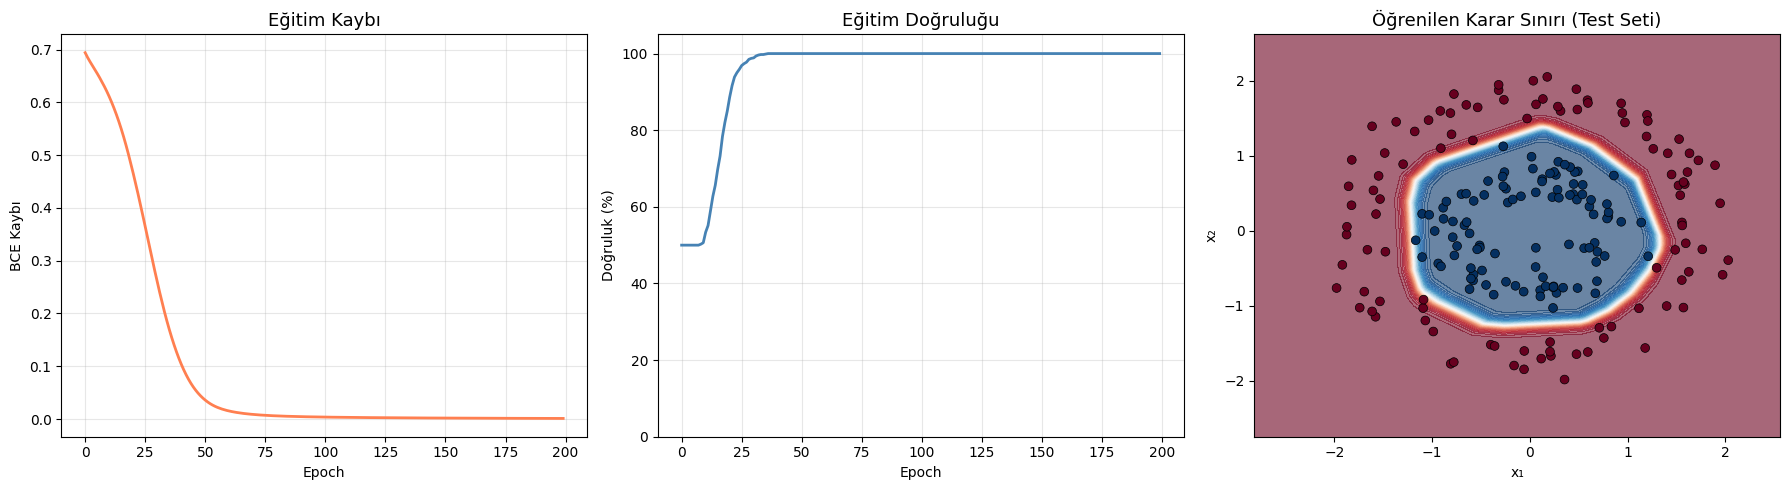

In [8]:
# Eğitim sürecini ve karar sınırını görselleştir

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Sol: Kayıp eğrisi ---
axes[0].plot(kayip_gecmisi, color='coral', linewidth=2)
axes[0].set_title('Eğitim Kaybı', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Kaybı')
axes[0].grid(True, alpha=0.3)

# --- Orta: Doğruluk eğrisi ---
axes[1].plot(np.array(dogruluk_gecmisi)*100, color='steelblue', linewidth=2)
axes[1].set_title('Eğitim Doğruluğu', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Doğruluk (%)')
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)

# --- Sağ: Karar sınırı ---
h = 0.02
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()]).to(device)
with torch.no_grad():
    Z = model(grid).cpu().numpy().reshape(xx.shape)

axes[2].contourf(xx, yy, Z, levels=50, cmap='RdBu', alpha=0.6)
axes[2].scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap='RdBu', edgecolors='k', linewidth=0.5, s=40)
axes[2].set_title('Öğrenilen Karar Sınırı (Test Seti)', fontsize=13)
axes[2].set_xlabel('x₁')
axes[2].set_ylabel('x₂')

plt.tight_layout()
plt.show()

## 7. MNIST ile Görüntü Sınıflandırma

El yazısı rakam veri seti — derin öğrenmenin "Merhaba Dünya"sı.

- **60.000** eğitim, **10.000** test görüntüsü
- Her görüntü: **28×28 piksel**, gri tonlamalı
- **10 sınıf**: rakamlar 0'dan 9'a

100%|██████████| 9.91M/9.91M [00:00<00:00, 46.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.21MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.3MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.77MB/s]


Eğitim seti boyutu : 60,000 görüntü
Test seti boyutu   : 10,000 görüntü
Batch boyutu       : 64
Eğitim batch sayısı: 938


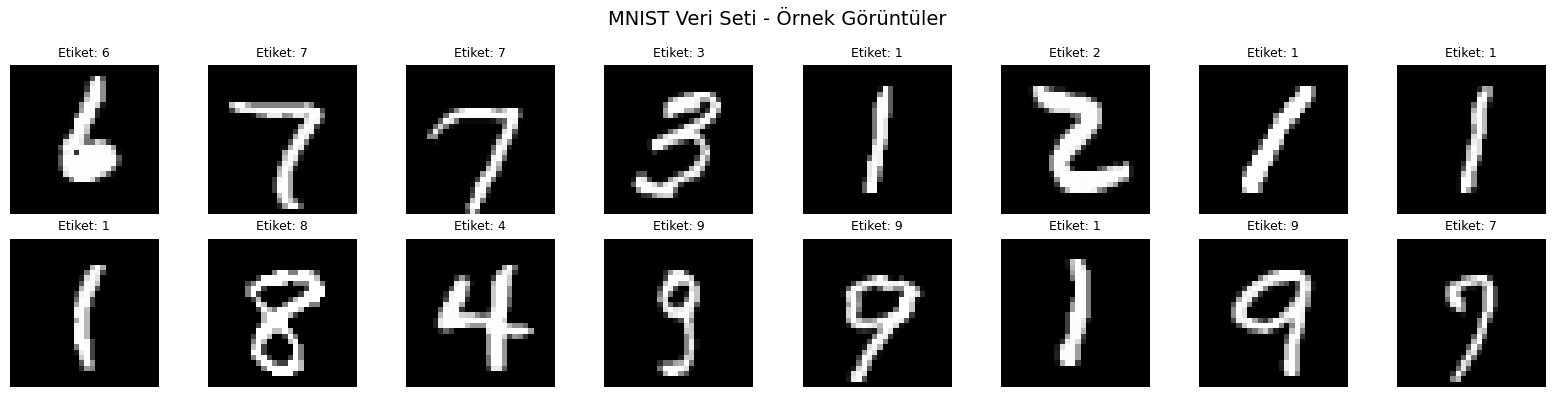

In [9]:
# MNIST veri setini indir ve yükle

transform = transforms.Compose([
    transforms.ToTensor(),                        # PIL/numpy → Tensor, [0,255] → [0,1]
    transforms.Normalize((0.1307,), (0.3081,))   # Ortalama ve std ile normalleştir
])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

# DataLoader: veriyi batch'lere böler, karıştırır
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Eğitim seti boyutu : {len(train_dataset):,} görüntü")
print(f"Test seti boyutu   : {len(test_dataset):,} görüntü")
print(f"Batch boyutu       : 64")
print(f"Eğitim batch sayısı: {len(train_loader)}")

# Birkaç örnek görüntü göster
ornekler, etiketler = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('MNIST Veri Seti - Örnek Görüntüler', fontsize=14)
for i, ax in enumerate(axes.flat):
    ax.imshow(ornekler[i].squeeze(), cmap='gray')
    ax.set_title(f'Etiket: {etiketler[i].item()}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
# MNIST için daha derin bir model

class MNISTSiniflandirici(nn.Module):
    """
    Tam bağlı (fully connected) MNIST sınıflandırıcı.
    Girdi: 28×28 = 784 piksel
    Çıktı: 10 sınıf olasılığı
    """
    def __init__(self):
        super(MNISTSiniflandirici, self).__init__()

        self.aglar = nn.Sequential(
            nn.Flatten(),          # (batch, 1, 28, 28) → (batch, 784)

            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),       # %30 nöronu rastgele sıfırla (overfitting önleme)

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)     # 10 sınıf — Softmax loss içinde uygulanacak
        )

    def forward(self, x):
        return self.aglar(x)

mnist_model = MNISTSiniflandirici().to(device)

# CrossEntropyLoss = LogSoftmax + NLLLoss
kayip_fn_mnist  = nn.CrossEntropyLoss()
optimizer_mnist = optim.Adam(mnist_model.parameters(), lr=0.001)

# Öğrenme hızı zamanlayıcısı: her 3 epoch'ta lr'yi %5 azalt
scheduler = optim.lr_scheduler.StepLR(optimizer_mnist, step_size=3, gamma=0.95)

print(f"Toplam Parametre: {sum(p.numel() for p in mnist_model.parameters()):,}")

Toplam Parametre: 235,146


In [11]:
# MNIST eğitim ve değerlendirme döngüsü

def egit_bir_epoch(model, loader, kayip_fn, optimizer):
    """Bir epoch eğitimi gerçekleştirir ve ortalama kayıp ile doğruluğu döndürür."""
    model.train()
    toplam_kayip, dogru, toplam = 0, 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        cikti = model(X_batch)
        kayip = kayip_fn(cikti, y_batch)
        kayip.backward()
        optimizer.step()

        toplam_kayip += kayip.item() * len(y_batch)
        tahmin = cikti.argmax(dim=1)   # En yüksek logit → tahmin edilen sınıf
        dogru += (tahmin == y_batch).sum().item()
        toplam += len(y_batch)

    return toplam_kayip / toplam, dogru / toplam

def degerlendir(model, loader, kayip_fn):
    """Model değerlendirmesi (gradyan hesaplamadan)."""
    model.eval()
    toplam_kayip, dogru, toplam = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            cikti = model(X_batch)
            kayip = kayip_fn(cikti, y_batch)
            toplam_kayip += kayip.item() * len(y_batch)
            dogru += (cikti.argmax(1) == y_batch).sum().item()
            toplam += len(y_batch)

    return toplam_kayip / toplam, dogru / toplam

# Eğit
epochs = 5
gecmis = {'train_kayip': [], 'train_acc': [], 'test_kayip': [], 'test_acc': []}

for epoch in range(1, epochs + 1):
    tr_k, tr_a = egit_bir_epoch(mnist_model, train_loader, kayip_fn_mnist, optimizer_mnist)
    te_k, te_a = degerlendir(mnist_model, test_loader, kayip_fn_mnist)
    scheduler.step()

    gecmis['train_kayip'].append(tr_k)
    gecmis['train_acc'].append(tr_a)
    gecmis['test_kayip'].append(te_k)
    gecmis['test_acc'].append(te_a)

    print(f"Epoch {epoch}/{epochs} | "
          f"Eğitim Kaybı: {tr_k:.4f} Acc: {tr_a*100:.2f}% | "
          f"Test Kaybı: {te_k:.4f} Acc: {te_a*100:.2f}%")

print(f"\n🎉 Final Test Doğruluğu: {gecmis['test_acc'][-1]*100:.2f}%")

Epoch 1/5 | Eğitim Kaybı: 0.3107 Acc: 90.63% | Test Kaybı: 0.1231 Acc: 96.16%
Epoch 2/5 | Eğitim Kaybı: 0.1527 Acc: 95.49% | Test Kaybı: 0.1057 Acc: 96.57%
Epoch 3/5 | Eğitim Kaybı: 0.1223 Acc: 96.25% | Test Kaybı: 0.0844 Acc: 97.40%
Epoch 4/5 | Eğitim Kaybı: 0.1022 Acc: 96.88% | Test Kaybı: 0.0761 Acc: 97.68%
Epoch 5/5 | Eğitim Kaybı: 0.0951 Acc: 96.97% | Test Kaybı: 0.0705 Acc: 97.78%

🎉 Final Test Doğruluğu: 97.78%


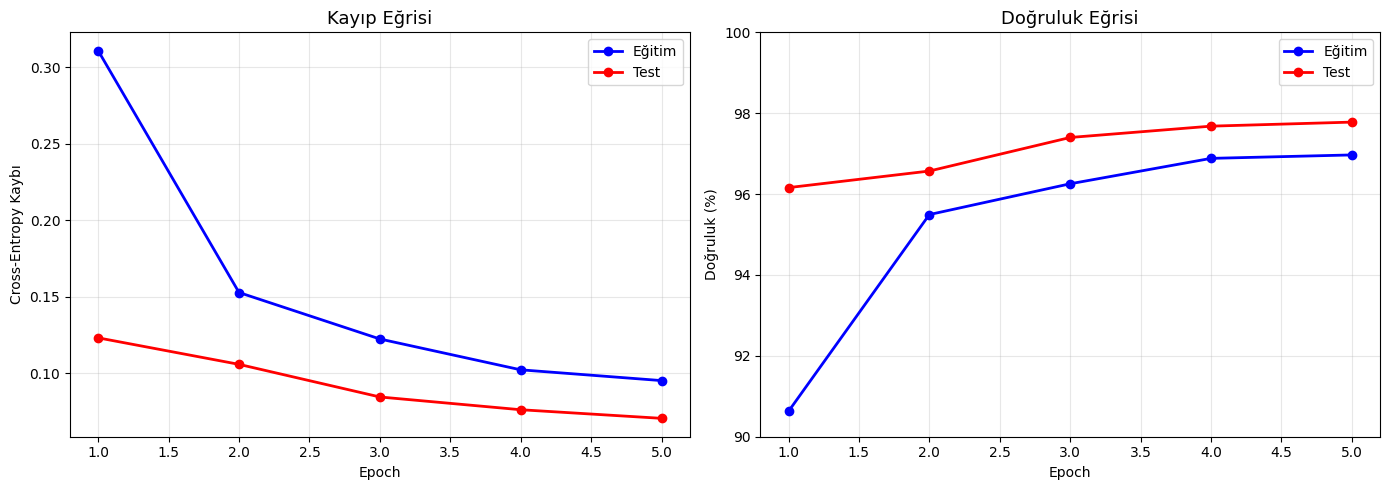

In [12]:
# Sonuçları görselleştir

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_aralik = range(1, len(gecmis['train_kayip']) + 1)

axes[0].plot(epochs_aralik, gecmis['train_kayip'], 'b-o', label='Eğitim', linewidth=2)
axes[0].plot(epochs_aralik, gecmis['test_kayip'],  'r-o', label='Test', linewidth=2)
axes[0].set_title('Kayıp Eğrisi', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Kaybı')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_aralik, [a*100 for a in gecmis['train_acc']], 'b-o', label='Eğitim', linewidth=2)
axes[1].plot(epochs_aralik, [a*100 for a in gecmis['test_acc']],  'r-o', label='Test', linewidth=2)
axes[1].set_title('Doğruluk Eğrisi', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Doğruluk (%)')
axes[1].set_ylim(90, 100)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Overfitting ve Regularizasyon

**Overfitting (Aşırı Uydurma):** Model eğitim verisini ezberler, yeni verilere genelleyemez.

```
                    İdeal Bölge
Kayıp │       \   /
      │  Test  \ /
      │  ───────V───────→ Underfitting | İyi | Overfitting
      │  Train ─────────────────────────────────→
```

### Çözümler:
| Yöntem | Açıklama |
|---|---|
| **Dropout** | Eğitimde rastgele nöronları kapat |
| **L2 Regularizasyon** | Ağırlıklara ceza ekle (weight decay) |
| **Early Stopping** | Validation kaybı artınca dur |
| **Data Augmentation** | Veriyi yapay olarak çoğalt |
| **Batch Normalization** | Katman girişlerini normalleştir |

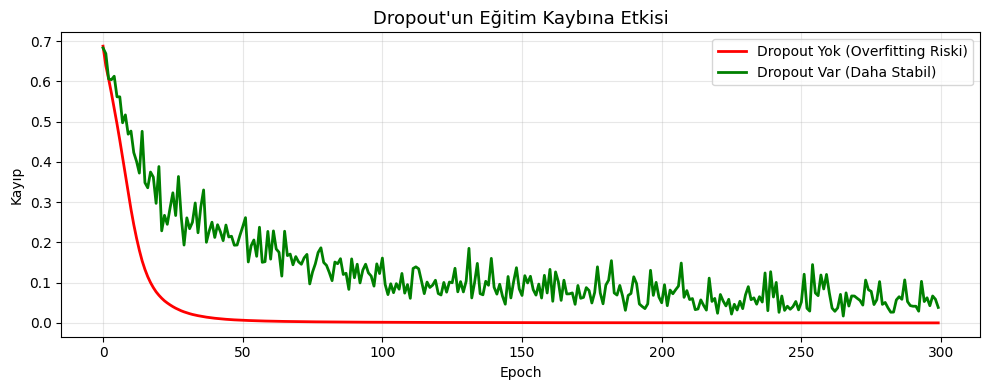

In [13]:
# Overfitting ve Dropout'un etkisini karşılaştır

# Küçük bir veri seti — overfitting'e meyilli
np.random.seed(42)
n = 100
X_kucuk = np.random.randn(n, 2)
y_kucuk = (X_kucuk[:, 0]**2 + X_kucuk[:, 1]**2 < 1.2).astype(float)

X_kucuk_t = torch.FloatTensor(X_kucuk)
y_kucuk_t = torch.FloatTensor(y_kucuk).unsqueeze(1)

def model_olustur(dropout_kullan=False):
    katmanlar = [
        nn.Linear(2, 64), nn.ReLU(),
    ]
    if dropout_kullan:
        katmanlar.append(nn.Dropout(0.5))  # %50 dropout
    katmanlar += [
        nn.Linear(64, 64), nn.ReLU(),
    ]
    if dropout_kullan:
        katmanlar.append(nn.Dropout(0.5))
    katmanlar += [nn.Linear(64, 1), nn.Sigmoid()]
    return nn.Sequential(*katmanlar)

def hizli_egit(model, X, y, epochs=300, lr=0.01):
    opt = optim.Adam(model.parameters(), lr=lr)
    fn = nn.BCELoss()
    kayiplar = []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()
        k = fn(model(X), y)
        k.backward()
        opt.step()
        kayiplar.append(k.item())
    return kayiplar

model_normal  = model_olustur(dropout_kullan=False)
model_dropout = model_olustur(dropout_kullan=True)

kayip_normal  = hizli_egit(model_normal,  X_kucuk_t, y_kucuk_t)
kayip_dropout = hizli_egit(model_dropout, X_kucuk_t, y_kucuk_t)

plt.figure(figsize=(10, 4))
plt.plot(kayip_normal,  label='Dropout Yok (Overfitting Riski)', color='red',   linewidth=2)
plt.plot(kayip_dropout, label='Dropout Var (Daha Stabil)',       color='green', linewidth=2)
plt.title('Dropout\'un Eğitim Kaybına Etkisi', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Özet ve Sonraki Adımlar

### Bu Notebook'ta Öğrendiklerimiz:

| Konu | Ne Öğrendik |
|---|---|
| **Sinir Ağı Temelleri** | Nöron, ağırlık, bias, katman |
| **Aktivasyon Fonksiyonları** | ReLU, Sigmoid, Tanh, Leaky ReLU |
| **İleri Yayılım** | Verinin ağdan geçişi |
| **Geri Yayılım** | Gradyan hesaplama, zincir kuralı |
| **Gradient Descent** | Ağırlık güncelleme, öğrenme hızı |
| **PyTorch** | nn.Module, DataLoader, optimizer, scheduler |
| **MNIST** | Gerçek veri ile eğitim |
| **Regularizasyon** | Dropout, overfitting önleme |

### Sonraki Adımlar:

1. **CNN (Evrişimsel Sinir Ağları)** — Görüntü işleme için
2. **RNN / LSTM** — Zaman serisi ve metin için
3. **Transfer Learning** — Önceden eğitilmiş modeller (ResNet, BERT)
4. **Transformerlar** — Modern NLP (GPT, BERT)
5. **GAN'lar** — Üretici Çekişmeli Ağlar

### Kaynaklar:
- 📖 [Deep Learning Book](https://www.deeplearningbook.org/) — Goodfellow, Bengio, Courville
- 🎓 [fast.ai](https://www.fast.ai/) — Pratik odaklı kurs
- 🔥 [PyTorch Tutorials](https://pytorch.org/tutorials/) — Resmi dökümantasyon
- 📺 [Andrej Karpathy YouTube](https://www.youtube.com/@AndrejKarpathy) — Derin anlatımlar

In [14]:
print("="*50)
print("  🧠 Derin Öğrenmeye Giriş Tamamlandı!")
print("="*50)
print()
print("Bu notebook'ta:")
print("  ✅ Sinir ağı sıfırdan oluşturuldu")
print("  ✅ Aktivasyon fonksiyonları görselleştirildi")
print("  ✅ Gradient descent simüle edildi")
print("  ✅ PyTorch ile gerçek model eğitildi")
print("  ✅ MNIST'te %97+ doğruluk elde edildi")
print("  ✅ Overfitting ve Dropout incelendi")
print()
print("Başarılar! 🚀")

  🧠 Derin Öğrenmeye Giriş Tamamlandı!

Bu notebook'ta:
  ✅ Sinir ağı sıfırdan oluşturuldu
  ✅ Aktivasyon fonksiyonları görselleştirildi
  ✅ Gradient descent simüle edildi
  ✅ PyTorch ile gerçek model eğitildi
  ✅ MNIST'te %97+ doğruluk elde edildi
  ✅ Overfitting ve Dropout incelendi

Başarılar! 🚀
